# Notebook 2 — Minimum local, minimum global et point de départ

## Objectifs

Dans ce notebook, nous allons :

- étudier une fonction non convexe d'une variable ;
- repérer ses minimums et maximums locaux ;
- appliquer la même descente de gradient depuis plusieurs points ;
- comprendre le rôle du point de départ ;
- introduire la notion de bassin d'attraction.

> La fonction dépend encore d'une seule variable $x$. Sa représentation reste donc une courbe dans un repère 2D.

## 1. Fonction étudiée

Nous utilisons :

$$f(x)=0.08x^2+\sin(2x)+0.15x$$

Sa dérivée, qui joue ici le rôle du gradient, est :

$$f'(x)=0.16x+2\cos(2x)+0.15$$

Sa dérivée seconde est :

$$f''(x)=0.16-4\sin(2x)$$

Le terme quadratique fait remonter la fonction vers $+\infty$ lorsque $x$ s'éloigne. Le terme sinusoïdal crée plusieurs vallées et plusieurs sommets. Le terme linéaire rend les vallées asymétriques afin qu'une seule soit la plus basse.

## 2. Importer les bibliothèques

In [1]:
# NumPy fournit les fonctions numériques, notamment sin, cos et linspace.
import numpy as np

# Matplotlib permet de visualiser la courbe et les trajectoires.
import matplotlib.pyplot as plt

# Ce style ajoute une grille discrète et améliore la lisibilité.
plt.style.use("seaborn-v0_8-whitegrid")

## 3. Programmer la fonction et ses dérivées

In [2]:
def fonction(x):
    """Calcule la valeur de la fonction non convexe."""
    # Le terme quadratique contrôle le comportement loin du centre.
    terme_quadratique = 0.08 * x**2

    # Le sinus crée les oscillations responsables des vallées locales.
    terme_sinusoidal = np.sin(2 * x)

    # Le terme linéaire incline légèrement toute la fonction.
    terme_lineaire = 0.15 * x

    # La valeur finale est la somme des trois composantes.
    return terme_quadratique + terme_sinusoidal + terme_lineaire


def gradient(x):
    """Calcule f'(x), la pente locale de la fonction."""
    return 0.16 * x + 2 * np.cos(2 * x) + 0.15


def derivee_seconde(x):
    """Calcule f''(x) pour classifier les points critiques."""
    return 0.16 - 4 * np.sin(2 * x)

### Rôle des trois fonctions

- `fonction(x)` donne la hauteur de la courbe ;
- `gradient(x)` donne la direction de montée ;
- `derivee_seconde(x)` décrit la courbure autour d'un point critique.

À un point critique, si $f''(x)>0$, la courbe ressemble localement à un bol : c'est un minimum local. Si $f''(x)<0$, elle ressemble à un bol renversé : c'est un maximum local.

## 4. Observer la forme générale de la fonction

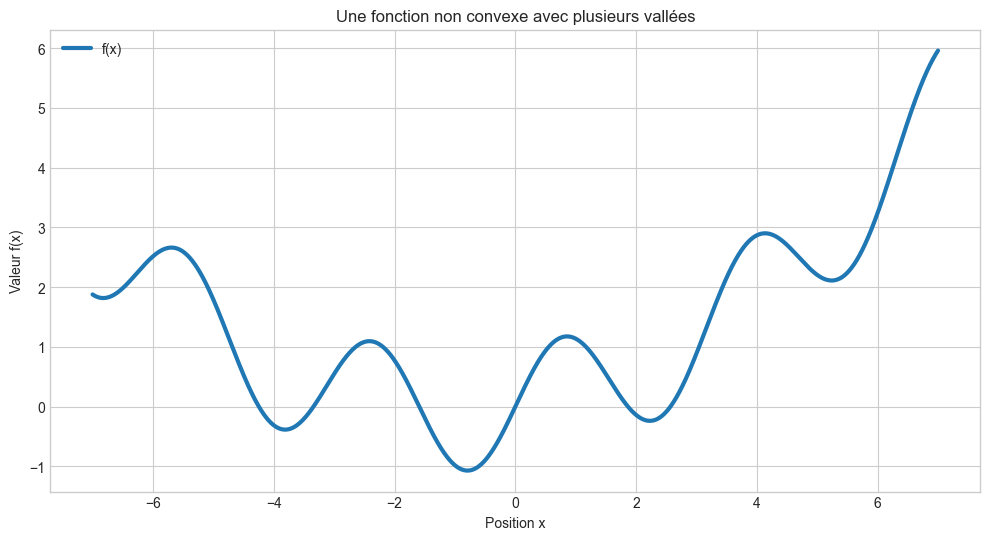

In [6]:
# Création de 20 001 valeurs entre -7 et 7.
# Une grille dense produit une courbe lisse et facilite la recherche des points critiques.
x_grille = np.linspace(-7, 7, 30_000)

# Calcul vectorisé de la fonction sur toute la grille.
y_grille = fonction(x_grille)

# Création de la figure et de son système d'axes.
fig, ax = plt.subplots(figsize=(12, 6))

# Tracé de la fonction non convexe.
ax.plot(x_grille, y_grille, linewidth=3, label="f(x)")

# Ajout des titres et des noms des axes.
ax.set_title("Une fonction non convexe avec plusieurs vallées")
ax.set_xlabel("Position x")
ax.set_ylabel("Valeur f(x)")
ax.legend()
plt.show()

La courbe n'est plus un bol unique. Chaque vallée peut attirer la descente de gradient. La vallée atteinte dépendra principalement de la position initiale.

## 5. Repérer approximativement les points critiques

Un point critique vérifie $f'(x)=0$. Sur une grille numérique, nous cherchons les endroits où le signe du gradient change.

In [7]:
# Calcul du gradient pour chaque valeur de la grille.
gradients_grille = gradient(x_grille)

# np.sign transforme chaque gradient en -1, 0 ou 1 selon son signe.
signes = np.sign(gradients_grille)

# np.diff compare deux signes voisins. Une différence non nulle indique un changement de signe.
indices_changement = np.where(np.diff(signes) != 0)[0]

# Pour chaque changement, nous prenons le milieu du petit intervalle correspondant.
points_critiques = (x_grille[indices_changement] + x_grille[indices_changement + 1]) / 2

# La dérivée seconde permet de séparer les minimums et les maximums locaux.
courbures = derivee_seconde(points_critiques)
minimums_locaux = points_critiques[courbures > 0]
maximums_locaux = points_critiques[courbures < 0]

# Parmi les minimums locaux, celui ayant la plus petite hauteur est le minimum global.
indice_global = np.argmin(fonction(minimums_locaux))
minimum_global = minimums_locaux[indice_global]

# Affichage des points trouvés avec leur classification.
print(f"{'x critique':>12} | {'f(x)':>10} | {'classification':>18}")
print("-" * 47)
for x_critique, courbure in zip(points_critiques, courbures):
    type_point = "minimum local" if courbure > 0 else "maximum local"
    if np.isclose(x_critique, minimum_global):
        type_point = "minimum global"
    print(f"{x_critique:12.3f} | {fonction(x_critique):10.3f} | {type_point:>18}")

  x critique |       f(x) |     classification
-----------------------------------------------
      -6.823 |      1.819 |      minimum local
      -5.693 |      2.664 |      maximum local
      -3.811 |     -0.383 |      minimum local
      -2.416 |      1.097 |      maximum local
      -0.791 |     -1.069 |     minimum global
       0.857 |      1.177 |      maximum local
       2.228 |     -0.236 |      minimum local
       4.136 |      2.903 |      maximum local
       5.239 |      2.113 |      minimum local


### Pourquoi peut-on parler de minimum global ?

Le sinus est toujours supérieur ou égal à $-1$. De plus, $0.15x$ est toujours supérieur ou égal à $-0.15|x|$. Nous avons donc :

$$f(x) ≥ 0.08x^2-0.15|x|-1$$

Pour $|x| ≥ 7$, cette borne est au moins égale à $1.87$ et elle augmente ensuite. Or la vallée centrale atteint environ $-1.069$. Aucun point situé hors de l'intervalle $[-7,7]$ ne peut donc être plus bas. La plus basse vallée trouvée dans l'intervalle est bien le minimum global sur $\mathbb{R}$.

### Limite de cette méthode

Les positions trouvées sont des approximations dépendant de la finesse de la grille. Elles suffisent pour la visualisation. Plus tard, nous pourrons étudier des méthodes numériques spécialisées pour résoudre exactement une équation comme $f'(x)=0$.

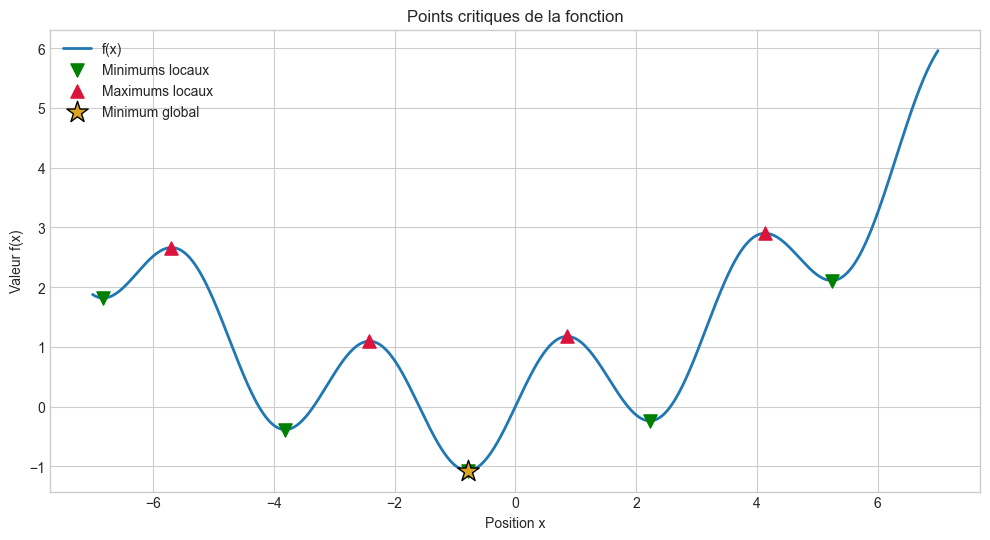

In [8]:
# Création d'une nouvelle figure.
fig, ax = plt.subplots(figsize=(12, 6))

# Tracé de la courbe principale.
ax.plot(x_grille, y_grille, linewidth=2, label="f(x)")

# Les triangles verts indiquent les minimums locaux.
ax.scatter(
    minimums_locaux,
    fonction(minimums_locaux),
    marker="v",
    s=90,
    color="green",
    zorder=5,
    label="Minimums locaux",
)

# Les triangles rouges indiquent les maximums locaux.
ax.scatter(
    maximums_locaux,
    fonction(maximums_locaux),
    marker="^",
    s=90,
    color="crimson",
    zorder=5,
    label="Maximums locaux",
)

# Une étoile distingue le minimum global des autres minimums.
ax.scatter(
    minimum_global,
    fonction(minimum_global),
    marker="*",
    s=260,
    color="goldenrod",
    edgecolor="black",
    zorder=6,
    label="Minimum global",
)

ax.set_title("Points critiques de la fonction")
ax.set_xlabel("Position x")
ax.set_ylabel("Valeur f(x)")
ax.legend()
plt.show()

## 6. Programmer la descente de gradient

Nous réutilisons le principe du notebook 1. Cette fois, la même fonction sera lancée depuis plusieurs positions.

In [9]:
def descente_gradient_1d(gradient_f, x_depart, taux, nombre_iterations):
    """Retourne toutes les positions visitées par la descente de gradient."""

    # Conversion du point de départ en nombre décimal.
    x = float(x_depart)

    # La première position de l'historique est le point de départ.
    historique = [x]

    # Répétition de la règle de mise à jour.
    for _ in range(nombre_iterations):
        # Calcul de la pente à la position actuelle.
        pente = gradient_f(x)

        # Déplacement opposé au gradient pour faire diminuer la fonction.
        x = x - taux * pente

        # Conservation de la nouvelle position.
        historique.append(x)

    # Retour sous forme de tableau NumPy.
    return np.array(historique)

## 7. Comparer plusieurs points de départ

Nous conservons exactement le même taux et le même nombre d'itérations. Seul le point initial change.

In [10]:
# Points de départ placés dans cinq vallées différentes.
points_depart = [-6.0, -4.5, 0.0, 1.5, 4.8]

# Même taux d'apprentissage pour toutes les expériences.
taux = 0.05

# Même durée d'optimisation pour toutes les expériences.
nombre_iterations = 120

# Ce dictionnaire associera chaque départ à sa trajectoire complète.
trajectoires = {}

# Exécution indépendante de la descente pour chaque point initial.
for x_depart in points_depart:
    trajectoires[x_depart] = descente_gradient_1d(
        gradient_f=gradient,
        x_depart=x_depart,
        taux=taux,
        nombre_iterations=nombre_iterations,
    )

# Affichage du résultat final de chaque expérience.
print(f"{'départ':>10} | {'arrivée':>10} | {'f(arrivée)':>12} | {'résultat':>16}")
print("-" * 58)
for x_depart, trajet in trajectoires.items():
    x_final = trajet[-1]
    resultat = "minimum global" if abs(x_final - minimum_global) < 0.01 else "minimum local"
    print(f"{x_depart:10.2f} | {x_final:10.3f} | {fonction(x_final):12.3f} | {resultat:>16}")

    départ |    arrivée |   f(arrivée) |         résultat
----------------------------------------------------------
     -6.00 |     -6.823 |        1.819 |    minimum local
     -4.50 |     -3.811 |       -0.383 |    minimum local
      0.00 |     -0.791 |       -1.069 |   minimum global
      1.50 |      2.228 |       -0.236 |    minimum local
      4.80 |      5.239 |        2.113 |    minimum local


Le point de départ $x=0$ rejoint le minimum global. Les autres départs restent dans leur vallée et convergent vers un minimum local plus élevé. L'algorithme ne compare pas toutes les vallées : il suit seulement la pente disponible autour de sa position actuelle.

## 8. Visualiser les différentes trajectoires

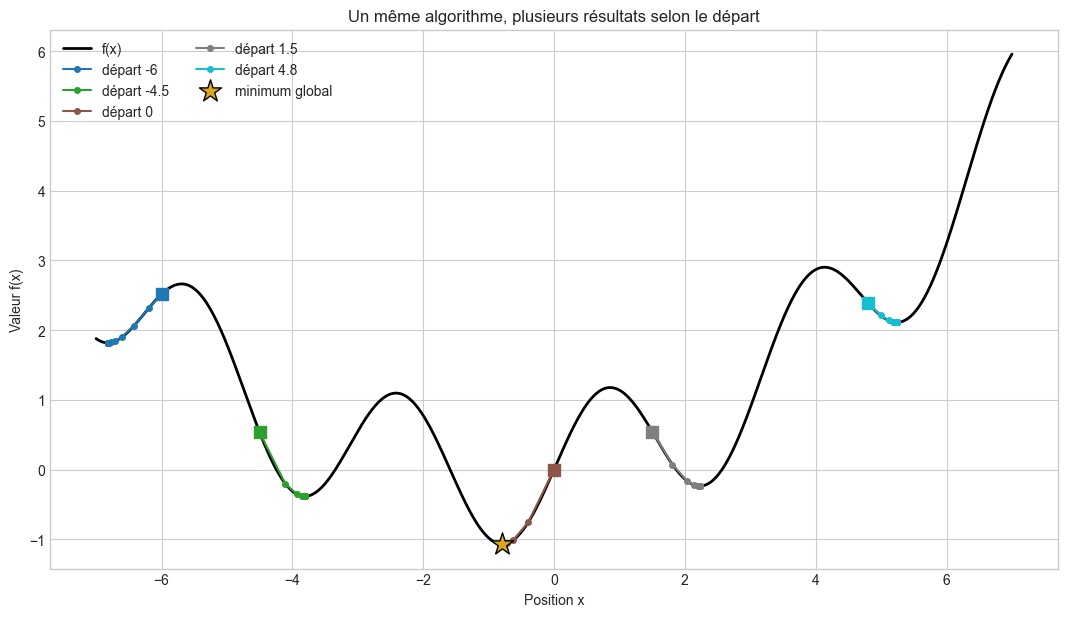

In [11]:
# Création d'une grande figure contenant toutes les expériences.
fig, ax = plt.subplots(figsize=(13, 7))

# Tracé de la fonction en arrière-plan.
ax.plot(x_grille, y_grille, color="black", linewidth=2, label="f(x)")

# Une couleur différente est attribuée à chaque point de départ.
couleurs = plt.cm.tab10(np.linspace(0, 1, len(points_depart)))

# Tracé de chaque trajectoire sur la courbe.
for couleur, (x_depart, trajet) in zip(couleurs, trajectoires.items()):
    # Pour garder le graphique lisible, nous affichons une position sur quatre.
    trajet_visible = trajet[::4]

    # Les points reliés montrent l'ordre des déplacements.
    ax.plot(
        trajet_visible,
        fonction(trajet_visible),
        "o-",
        color=couleur,
        markersize=4,
        label=f"départ {x_depart:g}",
    )

    # Un carré marque précisément la position initiale.
    ax.scatter(x_depart, fonction(x_depart), marker="s", s=80, color=couleur, zorder=6)

# Une étoile rappelle la position du minimum global.
ax.scatter(
    minimum_global,
    fonction(minimum_global),
    marker="*",
    s=280,
    color="goldenrod",
    edgecolor="black",
    zorder=7,
    label="minimum global",
)

ax.set_title("Un même algorithme, plusieurs résultats selon le départ")
ax.set_xlabel("Position x")
ax.set_ylabel("Valeur f(x)")
ax.legend(ncol=2)
plt.show()

### Bassin d'attraction

Un bassin d'attraction est l'ensemble des points de départ qui conduisent au même minimum. Les maximums locaux jouent approximativement le rôle de frontières entre les bassins : démarrer de part et d'autre d'un sommet conduit généralement à deux vallées différentes.

## 9. Comparer la convergence des cinq expériences

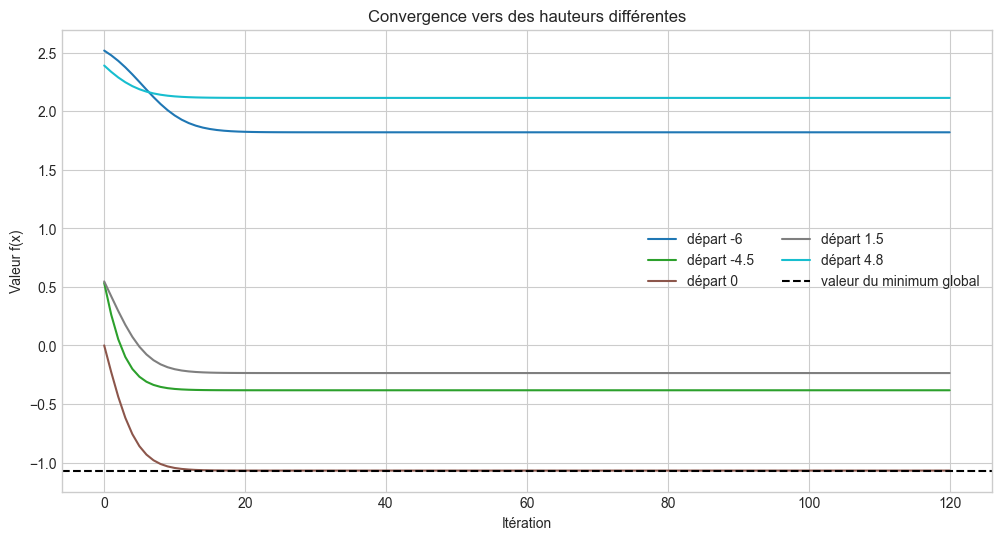

In [12]:
# Création du graphique de la valeur de la fonction selon l'itération.
fig, ax = plt.subplots(figsize=(12, 6))

# Chaque courbe représente une expérience complète.
for couleur, (x_depart, trajet) in zip(couleurs, trajectoires.items()):
    # Calcul de f(x) pour toutes les positions de la trajectoire.
    valeurs_trajet = fonction(trajet)

    # L'axe horizontal correspond au numéro de l'itération.
    iterations = np.arange(len(trajet))

    # Tracé de la diminution obtenue depuis ce point de départ.
    ax.plot(iterations, valeurs_trajet, color=couleur, label=f"départ {x_depart:g}")

# Ligne horizontale correspondant à la meilleure valeur possible.
ax.axhline(
    fonction(minimum_global),
    linestyle="--",
    color="black",
    label="valeur du minimum global",
)

ax.set_title("Convergence vers des hauteurs différentes")
ax.set_xlabel("Itération")
ax.set_ylabel("Valeur f(x)")
ax.legend(ncol=2)
plt.show()

## 10. Ce qu'il faut retenir

1. Une fonction non convexe possède plusieurs vallées possibles.
2. La descente suit uniquement l'information locale donnée par le gradient.
3. Deux initialisations différentes peuvent produire deux résultats différents.
4. Un gradient presque nul indique un point critique, pas nécessairement le minimum global.
5. La fonction peut diminuer à chaque étape tout en terminant dans une mauvaise vallée.
6. En machine learning, l'initialisation des paramètres peut donc influencer le modèle obtenu.

## 11. Exercice

1. Choisis les points de départ `-5.8`, `-2.5`, `0.9` et `4.2`.
2. Avant d'exécuter le code, prédis la vallée atteinte par chaque point.
3. Lance la descente avec `taux = 0.05` et `nombre_iterations = 120`.
4. Compare ta prédiction avec la position finale.
5. Explique le rôle des maximums locaux comme frontières entre les bassins.

### Bonus

Démarre exactement sur un maximum local détecté. Observe ce qui se produit, puis ajoute une très petite perturbation, par exemple `+ 0.001`. Explique pourquoi les deux résultats peuvent être très différents.